In [7]:
%matplotlib widget

In [8]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [9]:
spectra = []

for i in range(1, 25):
    df = pd.read_csv(f"Spectrum_{i}_gas_exp.csv")
    spectra.append(df)
    
SNR_HA = pd.read_csv("SNR_HA.csv")
SNR_HB = pd.read_csv("SNR_HB.csv") 
SNR_NII_2 = pd.read_csv("SNR_NII_2.csv") 
SNR_OIII_2 = pd.read_csv("SNR_OIII_2.csv") 
SNR_SII_1 = pd.read_csv("SNR_SII_1.csv") 

In [10]:
SNR_OIII_2

,Unnamed: 0,SNR,Signal,Noise
0,Spettro_1,NaN,NaN,NaN
1,Spettro_2,3.522,0.047,0.013
2,Spettro_3,1.794,0.025,0.014
3,Spettro_4,47.233,0.301,0.006
4,Spettro_5,16.398,0.195,0.012
5,Spettro_6,4.387,0.068,0.016
6,Spettro_7,4.064,0.036,0.009
7,Spettro_8,0.194,0.002,0.012
8,Spettro_9,7.462,0.129,0.017
9,Spettro_10,16.271,0.456,0.028


In [11]:
def Ku03(x):
    # AGN selection based on Kauffman et al. 2003
    # log OIII/Hb > 0.61/(log NII/Ha - 0.05) + 1.3
    return 0.61/(x - 0.05) + 1.3

def Ke01(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.61/(log NII/Ha - 0.47) + 1.19
     return 0.61/(x - 0.47) + 1.19

def S06(x):
    # AGN selection based on Stasinska et al 2006
     # log OIII/Hb > 0.29/(log NII/Ha +0.20) + 0.96
    return 0.29/(x + 0.20) + 0.96

def C10(x):
 # Seyfert–LINER line based on Cid Fernandes et al 2010
    return 1.01*x + 0.48

def Ke01_SII(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.72/(log SII/Ha - 0.32) + 1.3
     return 0.72/(x - 0.32) + 1.3

def Ke06(x):
    #Seyfert–LINER line
    return 1.89* x + 0.76

def error_ratio(err_1, err_2, flux_1, flux_2):
    try:
        e_1 = err_1 / (flux_1 * np.log(10)) if flux_1 != 0 else np.nan
        e_2 = err_2 / (flux_2 * np.log(10)) if flux_2 != 0 else np.nan
        return np.sqrt(e_1**2 + e_2**2)
    except:
        return np.nan

def ratio(spectrum_1):
    flux = spectrum_1['Flux']
    err_flux = spectrum_1['Error_flux']

    OIII = flux[7]
    HB   = flux[0]
    NII  = flux[11]
    HA   = flux[1]
    SII  = flux[2]

    OIII_HB = np.log10(OIII / HB) if OIII > 0 and HB > 0 else np.nan
    NII_HA  = np.log10(NII / HA)  if NII > 0 and HA > 0 else np.nan
    SII_HA  = np.log10(SII / HA)  if SII > 0 and HA > 0 else np.nan

    err_OIII_HB = error_ratio(err_flux[7], err_flux[0], OIII, HB)
    err_NII_HA  = error_ratio(err_flux[11], err_flux[1], NII, HA)
    err_SII_HA  = error_ratio(err_flux[2], err_flux[1], SII, HA)

    return OIII_HB, NII_HA, SII_HA, err_OIII_HB, err_NII_HA, err_SII_HA

def evaluation_SNR(SNR_HA, SNR_HB, SNR_NII, SNR_SII, SNR_OIII):
    if (SNR_HB < 0) and (SNR_OIII >= 3) and (SNR_HA >= 3) and (SNR_NII >= 3) and (SNR_SII >= 3):
        return True 
    elif (SNR_HB >= 3) and (SNR_OIII >= 3) and (SNR_HA >= 3) and (SNR_NII >= 3) and (SNR_SII >= 3):
        return True 
    else: return False 

Nan: 1
nan nan nan nan nan
Nan: 2
10.255 2.322 0.469 3.898 3.522
Nan: 3
8.669 1.144 2.624 3.182 1.794
Nan: 7
25.002 1.523 6.534 4.522 4.064
Nan: 8
20.052 -0.088 7.715 5.021 0.194
Nan: 22
17.106 0.374 6.509 3.128 6.56
Nan: 23
0.439 0.888 -2.86 0.528 -0.009
Nan: 24
8.419 0.457 4.175 2.076 3.768


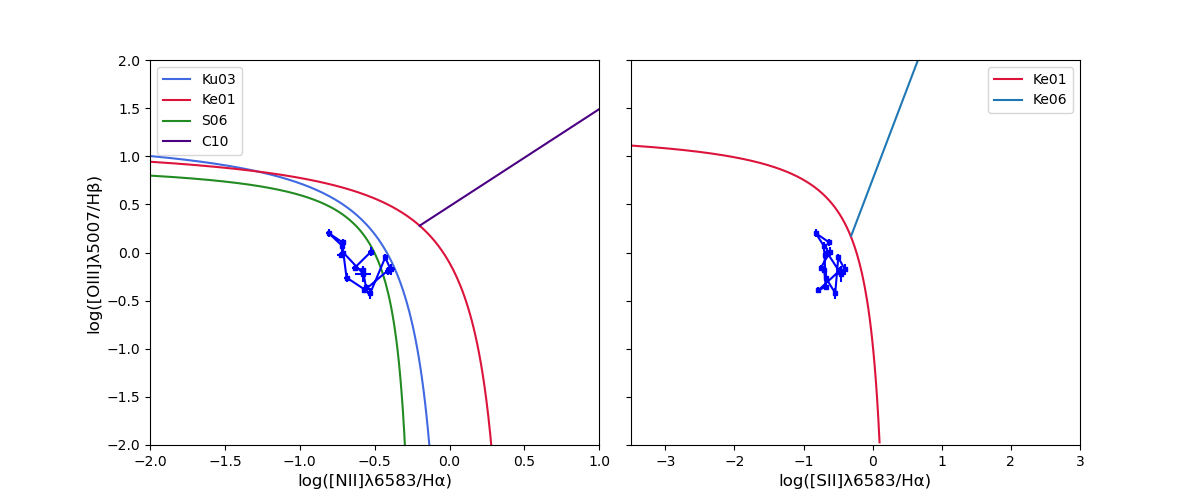

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.2, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
ax[0].plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
ax[0].plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
ax[0].plot(x3, C10(x3), label = 'C10', color = 'indigo')

x = np.linspace(-3.5, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')

NII_HA =[]
OIII_HB =[]
SII_HA =[]
NII_HA_err =[]
OIII_HB_err =[]
SII_HA_err =[]
for i in range(len(spectra)):
    SNR = evaluation_SNR(SNR_HA['SNR'][i], SNR_HB['SNR'][i], SNR_NII_2['SNR'][i], SNR_SII_1['SNR'][i], SNR_OIII_2['SNR'][i])
    if SNR == True: 
        spectrum = spectra[i]
        oiii_hb, nii_ha, sii_ha, err_oiii_hb, err_nii_ha, err_sii_ha = ratio(spectrum)
        if np.isnan(oiii_hb) == False:
            OIII_HB.append(oiii_hb)
            OIII_HB_err.append(err_oiii_hb)
        if np.isnan(sii_ha) == False:
            SII_HA.append(sii_ha)
            SII_HA_err.append(err_sii_ha)
        if np.isnan(nii_ha) == False:    
            NII_HA.append(nii_ha)
            NII_HA_err.append(err_nii_ha)
    
    else: 
        oiii_hb = np.nan
        nii_ha = np.nan
        sii_ha = np.nan
        err_oiii_hb = np.nan
        err_nii_ha = np.nan
        err_sii_ha = np.nan
        NII_HA.append(nii_ha)
        OIII_HB.append(oiii_hb)
        SII_HA.append(sii_ha)
        NII_HA_err.append(err_nii_ha)
        OIII_HB_err.append(err_oiii_hb)
        SII_HA_err.append(err_sii_ha)
        print('Nan:', i+1)
        print(SNR_HA['SNR'][i], SNR_HB['SNR'][i], SNR_NII_2['SNR'][i], SNR_SII_1['SNR'][i], SNR_OIII_2['SNR'][i])
        
OIII_HB_ok = []
SII_HA_ok = []
NII_HA_ok = []
OIII_HB_err_ok = []
SII_HA_err_ok = []
NII_HA_err_ok = []

for i in range(len(spectra)):
    if np.isnan(OIII_HB[i]) == False:
        OIII_HB_ok.append(OIII_HB[i])
        OIII_HB_err_ok.append(OIII_HB_err[i])
    if np.isnan(SII_HA[i]) == False:
        SII_HA_ok.append(SII_HA[i])
        SII_HA_err_ok.append(SII_HA_err[i])
    if np.isnan(NII_HA[i]) == False:
        NII_HA_ok.append(NII_HA[i])
        NII_HA_err_ok.append(NII_HA_err[i])
    
ax[0].errorbar(NII_HA, OIII_HB, OIII_HB_err, NII_HA_err, color='blue', marker= 's', linestyle='-', markersize = 3)   
ax[0].errorbar(NII_HA[0], OIII_HB[0], OIII_HB_err[0], NII_HA_err[0], color='red', marker= 's', linestyle='-', markersize = 3) 
ax[0].errorbar(NII_HA[-1], OIII_HB[-1], OIII_HB_err[-1], NII_HA_err[-1], color='orange', marker= 's', linestyle='-', markersize = 3) 
ax[1].errorbar(SII_HA, OIII_HB, OIII_HB_err, NII_HA_err, color='blue', marker= 's', linestyle='-', markersize = 3)
ax[1].errorbar(SII_HA[0], OIII_HB[0], OIII_HB_err[0], NII_HA_err[0], color='green', marker= 's', linestyle='-', markersize = 3)
ax[1].errorbar(SII_HA[-1], OIII_HB[-1], OIII_HB_err[-1], NII_HA_err[-1], color='purple', marker= 's', linestyle='-', markersize = 3)

ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].set_xlim(-3.5, 3)
ax[1].set_ylim(-2, 2)
ax[1].set_xlabel('log([SII]λ6583/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.07)
#plt.savefig('BPT_grad.png', bbox_inches='tight')

In [13]:
NII_HA_err_ok

[0.02549269958527974,
 0.019772495370957512,
 0.05501386809853323,
 0.017594232712410743,
 0.01493072052649056,
 0.015350838425167265,
 0.011797938510045992,
 0.015803917619019753,
 0.0168866356478566,
 0.028589725194957675,
 0.01763748709261184,
 0.021423029517111565,
 0.01774685107256847,
 0.01351330151050993,
 0.018480901932394017,
 0.015239471750130535]

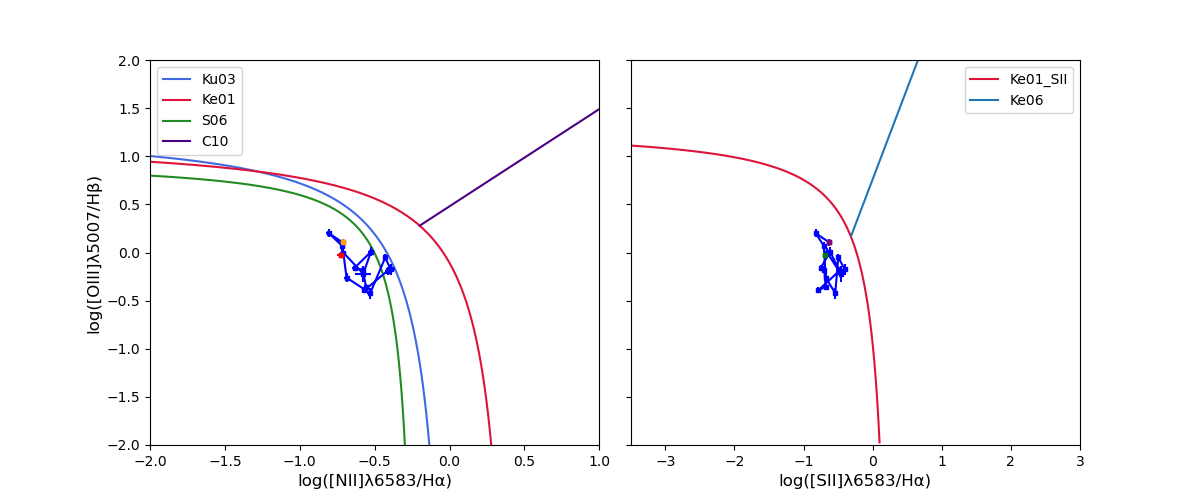

In [14]:
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.2, 5, num=200)
ax2[0].plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
ax2[0].plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
ax2[0].plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
ax2[0].plot(x3, C10(x3), label = 'C10', color = 'indigo')

x = np.linspace(-3.5, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax2[1].plot(x, Ke01_SII(x), label = 'Ke01_SII', color = 'crimson')
ax2[1].plot(x1, Ke06(x1), label = 'Ke06')

ax2[0].errorbar(NII_HA_ok, OIII_HB_ok, OIII_HB_err_ok, NII_HA_err_ok, color='blue', marker= 's', linestyle='-', markersize = 3)   
ax2[0].errorbar(NII_HA_ok[0], OIII_HB_ok[0], OIII_HB_err_ok[0], NII_HA_err_ok[0], color='red', marker= 's', linestyle='-', markersize = 3) 
ax2[0].errorbar(NII_HA_ok[-1], OIII_HB_ok[-1], OIII_HB_err_ok[-1], NII_HA_err_ok[-1], color='orange', marker= 's', linestyle='-', markersize = 3) 
ax2[1].errorbar(SII_HA_ok, OIII_HB_ok, OIII_HB_err_ok, NII_HA_err_ok, color='blue', marker= 's', linestyle='-', markersize = 3)
ax2[1].errorbar(SII_HA_ok[0], OIII_HB_ok[0], OIII_HB_err_ok[-1], NII_HA_err_ok[0], color='green', marker= 's', linestyle='-', markersize = 3)
ax2[1].errorbar(SII_HA_ok[-1], OIII_HB_ok[-1], OIII_HB_err_ok[-1], NII_HA_err_ok[-1], color='purple', marker= 's', linestyle='-', markersize = 3)

ax2[0].set_xlim(-2, 1)
ax2[0].set_ylim(-1.5, 2)
ax2[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax2[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax2[0].legend()

ax2[1].set_xlim(-3.5, 3)
ax2[1].set_ylim(-2, 2)
ax2[1].set_xlabel('log([SII]λ6583/Hα)', fontsize=12)
ax2[1].legend()

plt.subplots_adjust(wspace=0.07)
plt.savefig('BPT_grad.png', bbox_inches='tight')